In [ ]:
# The visualizations were aided by generative AI
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

df = pd.read_csv("survey_raw.csv").rename(columns={
    "Do you rely on Large language models in your (professional/school) work": "llm_work",
    "Do you use also use Large language models for entertainment in your free time": "llm_entertainment",
    "Are there times when you are missing players to start a group gaming session": "missing_players",
    "What is your attitude towards using Large language models in games": "attitude_llm_games",
    "Did you feel that other players changed their behavior during the game": "behavior_change",
    "Did you feel that discussion affected how players played": "discussion_effect",
    "Do you see potential in substitute players powered by Artificial Intelligence": "ai_substitute_potential",
    "You overall enjoyment of the experience": "enjoyment",
}).drop(columns=["UserID"])

df.describe()

,llm_work,llm_entertainment,missing_players,attitude_llm_games,behavior_change,discussion_effect,ai_substitute_potential,enjoyment
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,3.571429,2.142857,3.190476,3.238095,3.952381,3.571429,3.952381,4.333333
std,1.398979,1.195229,1.123345,0.995227,0.973457,1.247855,0.920662,0.856349
min,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000
25%,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000
50%,4.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,5.000000
75%,5.000000,3.000000,4.000000,4.000000,5.000000,4.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [2]:
cols = df.select_dtypes("number").columns

rho_df = pd.DataFrame(
    [[spearmanr(df[ci], df[cj]).statistic for cj in cols] for ci in cols],
    index=cols, columns=cols
).round(3)

p_df = pd.DataFrame(
    [[spearmanr(df[ci], df[cj]).pvalue for cj in cols] for ci in cols],
    index=cols, columns=cols
).round(6)

print("Spearman ρ:"); display(rho_df)
print("p-values:");   display(p_df)

Spearman ρ:


,llm_work,llm_entertainment,missing_players,attitude_llm_games,behavior_change,discussion_effect,ai_substitute_potential,enjoyment
llm_work,1.000,0.548,0.149,0.224,0.055,0.028,0.540,0.118
llm_entertainment,0.548,1.000,0.343,0.205,0.384,0.349,0.749,0.274
missing_players,0.149,0.343,1.000,0.113,0.436,0.460,0.384,0.204
attitude_llm_games,0.224,0.205,0.113,1.000,0.276,0.090,0.433,0.363
behavior_change,0.055,0.384,0.436,0.276,1.000,0.600,0.595,0.292
discussion_effect,0.028,0.349,0.460,0.090,0.600,1.000,0.378,0.256
ai_substitute_potential,0.540,0.749,0.384,0.433,0.595,0.378,1.000,0.616
enjoyment,0.118,0.274,0.204,0.363,0.292,0.256,0.616,1.000


p-values:


,llm_work,llm_entertainment,missing_players,attitude_llm_games,behavior_change,discussion_effect,ai_substitute_potential,enjoyment
llm_work,0.000000,0.010181,0.517894,0.330106,0.812703,0.903494,0.011592,0.611023
llm_entertainment,0.010181,0.000000,0.128535,0.373690,0.085925,0.121016,0.000093,0.228931
missing_players,0.517894,0.128535,0.000000,0.627171,0.048427,0.035916,0.085664,0.375784
attitude_llm_games,0.330106,0.373690,0.627171,0.000000,0.225530,0.696761,0.049980,0.106020
behavior_change,0.812703,0.085925,0.048427,0.225530,0.000000,0.004048,0.004400,0.199568
discussion_effect,0.903494,0.121016,0.035916,0.696761,0.004048,0.000000,0.091046,0.262411
ai_substitute_potential,0.011592,0.000093,0.085664,0.049980,0.004400,0.091046,0.000000,0.002928
enjoyment,0.611023,0.228931,0.375784,0.106020,0.199568,0.262411,0.002928,0.000000


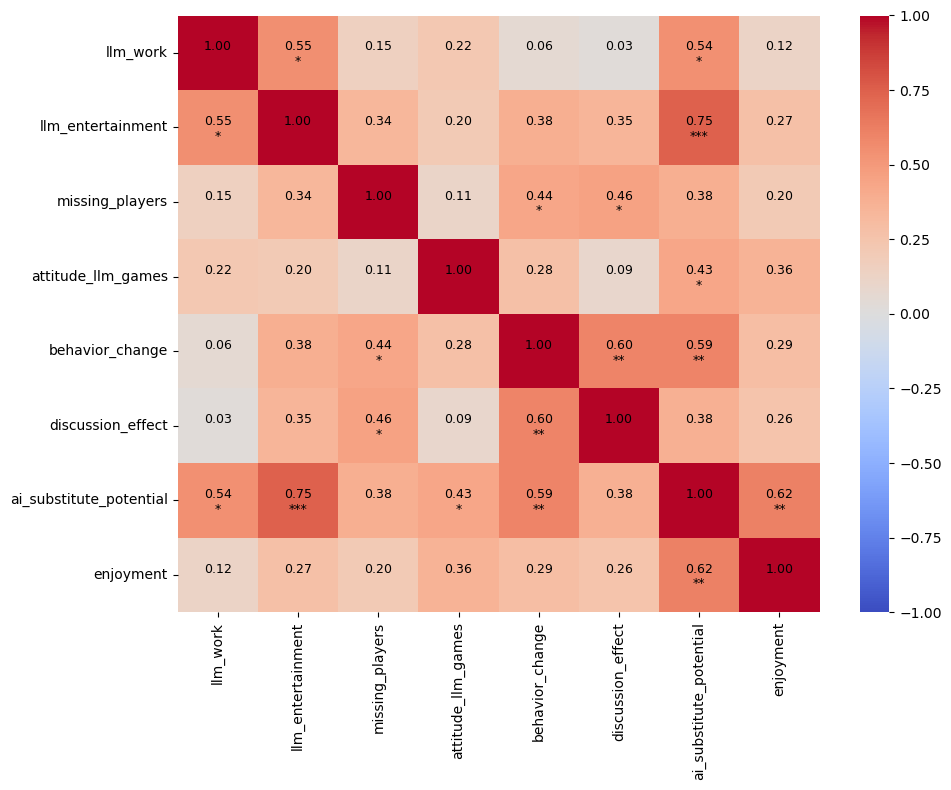

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rho_df, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)

for i, ci in enumerate(rho_df.index):
    for j, cj in enumerate(rho_df.columns):
        rho = rho_df.loc[ci, cj]
        p   = p_df.loc[ci, cj]
        if ci == cj:
            sig = ""
        elif p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = ""
        ax.text(j + 0.5, i + 0.42, f"{rho:.2f}", ha="center", va="center", fontsize=9)
        ax.text(j + 0.5, i + 0.62, sig, ha="center", va="center", fontsize=9, color="black")


plt.tight_layout()
plt.show()
